# Les 8 - Scheduling

## Herhaling

Let op: We gebruiken BeautifulSoup(response.content, "xml") in plaats van "html.parser". XML is strenger dan HTML. Hiervoor is lxml nodig: pip install lxml.

We bewaren elk artikel bij in een json-file met de naam vrt_nieuws.json

In [ ]:
from bs4 import BeautifulSoup
import requests
import json
import time

start = time.time()

url = "***"
response = requests.get(url)

with open("news.json","r") as file:
    news = json.load(file)

titles = [n["titel"] for n in news]

soup = BeautifulSoup(response.content, "xml")
items = soup.find_all("item")
count = 0
for item in items:

    if item.title.text not in titles:
        count += 1
        news.append(
            {
                "titel": item.title.text,
                "artikel":item.description.text,
                "datum":item.pubDate.text
            }
        )

with open("news.json","w") as file:
    json.dump(news, file)

print(count, "artikels toegevoegd")
end = time.time()

print(end-start,"zoveel seconden geduurd")

## Tijd & datum

In [14]:
import time
import winsound

print(time.ctime())
print(time.time())


frequency = 1000 
duration = 500  

for i in range(0,5):
    time.sleep(5)
    winsound.Beep(frequency, duration)
    print("BEEP")


Tue Mar 31 15:52:02 2026
1774965122.769073
BEEP
BEEP
BEEP
BEEP
BEEP


In [ ]:
# ! py -m pip install schedule
import schedule

def BEEP():
    print("BEEP")

schedule.every().second.do(BEEP)

while True:
    schedule.run_pending()


In [13]:
import datetime

print(datetime.datetime.now())

date = datetime.datetime.now()
print(date.day)
print(date.weekday)

date += datetime.timedelta(days=50)
print(date)

2026-03-31 15:36:02.364646
31
<built-in method weekday of datetime.datetime object at 0x0000014B2A041350>
2026-05-20 15:36:02.365252


## Multi threading

in een aparte file!

## Launching programs

In [ ]:
import subprocess

subprocess.Popen(r"C:\WINDOWS\System32\calc.exe")

subprocess.Popen(['start', 'test.txt'], shell=True)

<Popen: returncode: None args: ['start', 'test.txt']>

In [25]:
import webbrowser

webbrowser.open("www.google.com")

True

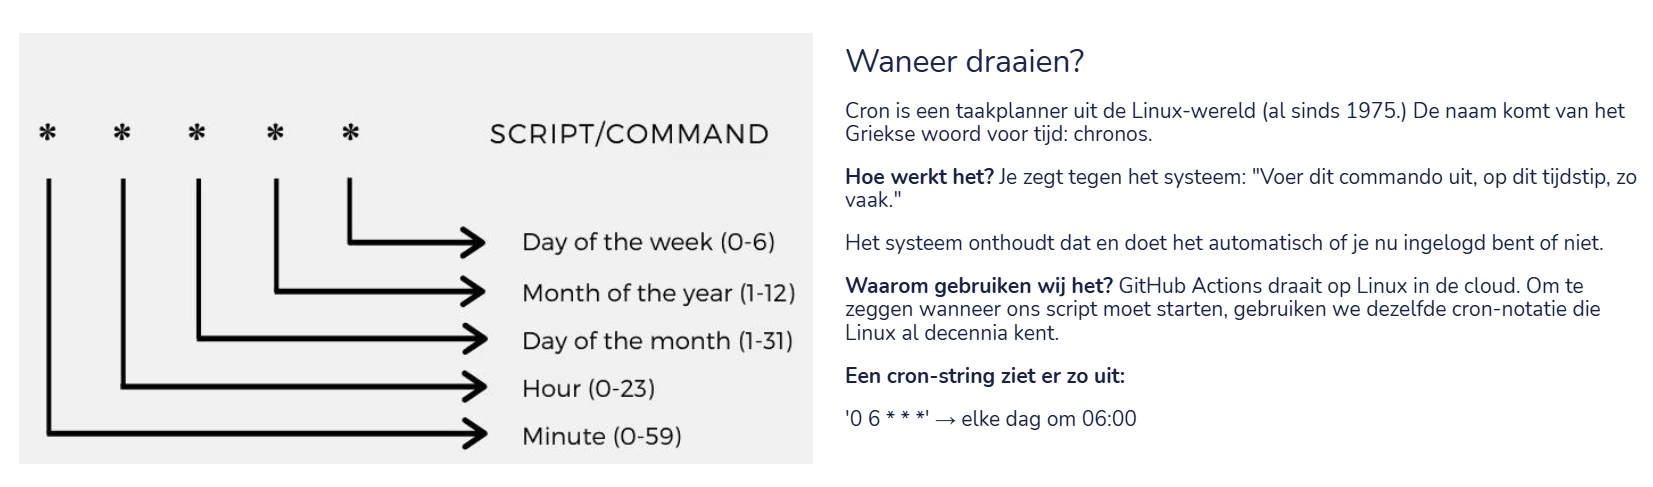

Stap 1 - Maak de mappenstructuur aan:
- jouw-repo/ --> script & json
- jouw-repo/.github/workflows/ --> yaml-file

Stap 2 - Schrijfrechten geven:
Repo → Settings → Actions → General → Workflow permissions → Read and write permissions → Save

Stap 3 - Manueel testen - GitHub → Actions → naam workflow → Run workflow

Vergeet niet om logs te bekijken